In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("my_netflix_dataset.csv")
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.shape


(8807, 12)

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df.isnull().sum()


,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [8]:
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')
df['listed_in'] = df['listed_in'].fillna('Unknown')


In [9]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df.dropna(subset=['date_added'], inplace=True)

df['year_added'] = df['date_added'].dt.year


In [10]:
df['type'].value_counts()


,count
type,
Movie,6131
TV Show,2578


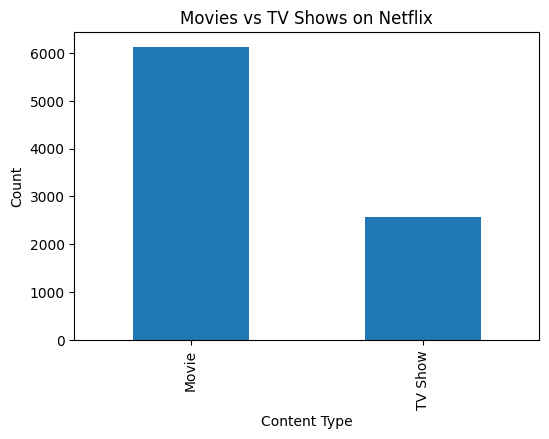

In [11]:
plt.figure(figsize=(6,4))
df['type'].value_counts().plot(kind='bar')
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()


In [13]:
content_by_year = df['year_added'].value_counts().sort_index()


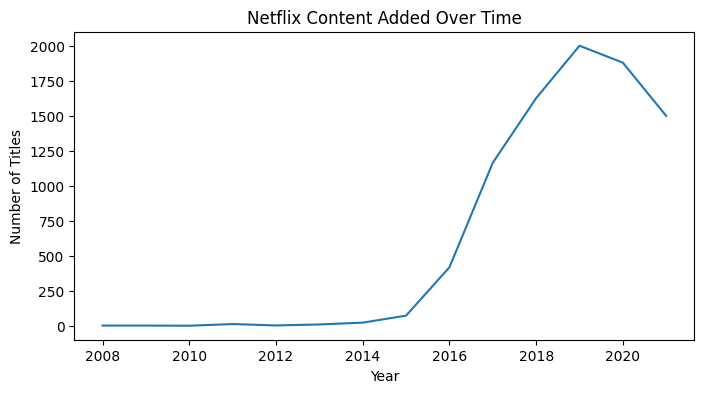

In [14]:
plt.figure(figsize=(8,4))
plt.plot(content_by_year.index, content_by_year.values)
plt.title("Netflix Content Added Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()


In [15]:
top_countries = (
    df['country']
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)
top_countries


,count
country,
United States,3643
India,1045
Unknown,827
United Kingdom,787
Canada,432
France,389
Japan,314
Spain,228
South Korea,226


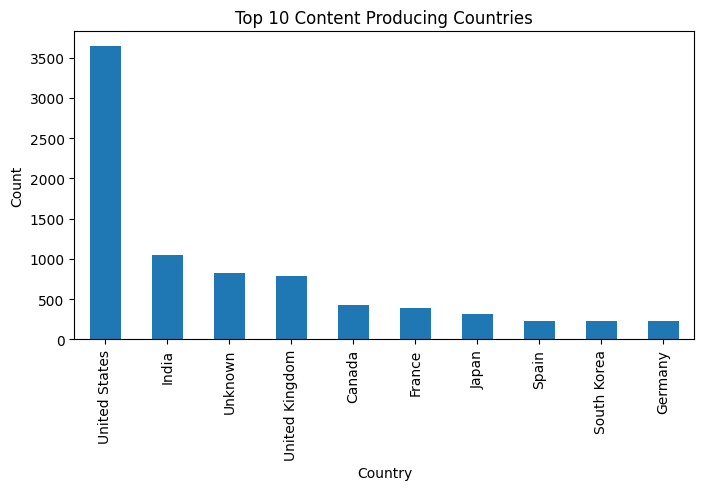

In [16]:
plt.figure(figsize=(8,4))
top_countries.plot(kind='bar')
plt.title("Top 10 Content Producing Countries")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()


In [17]:
top_genres = (
    df['listed_in']
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)
top_genres


,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1328
Documentaries,869
Action & Adventure,859
Independent Movies,756
TV Dramas,739
Children & Family Movies,641


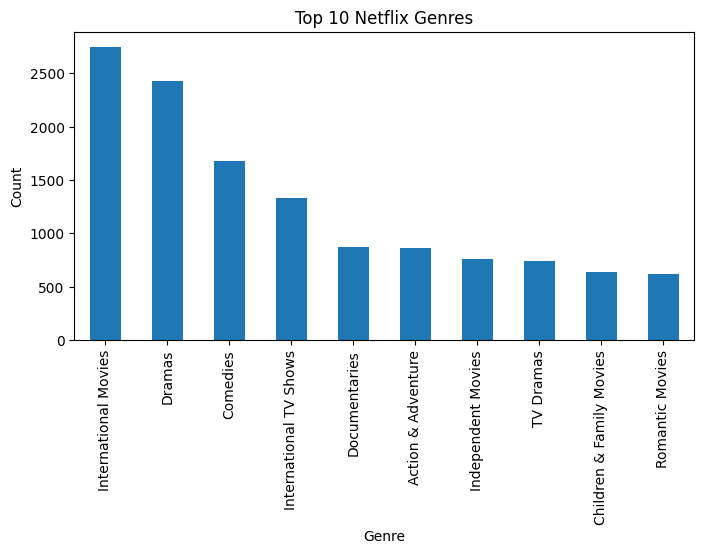

In [18]:
plt.figure(figsize=(8,4))
top_genres.plot(kind='bar')
plt.title("Top 10 Netflix Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()


Insights

*   Netflix has more movies than TV shows
*   Content additions increased significantly after 2016
*   USA dominates content production
* Drama and Comedy are the most popular genres  








